In [3]:
# Phase 1: RFM Feature Engineering & Cleaning
# For segmentation, standard demographic data isn't enough; you need behavioral data. The industry standard is the RFM Model:

# Recency (R): How many days ago was their last purchase? (Lower is better)

# Frequency (F): How many times do they buy in a year? (Higher is better)

# Monetary (M): How much total money have they spent? ('')

#Import Foundations & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#retail transaction dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"
print("Libraries imported successfully.")

Libraries imported successfully.


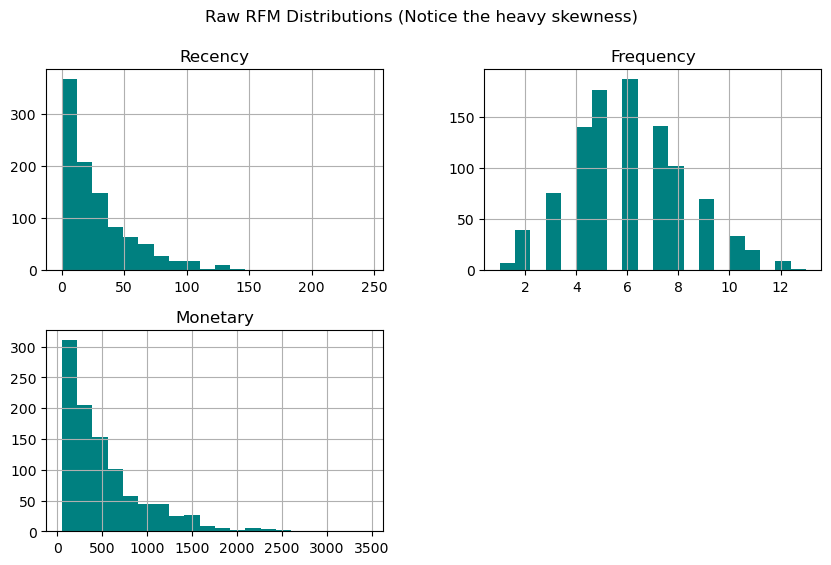

In [4]:
#Simulating/Structuring the RFM Base
np.random.seed(42)
n_customers = 1000

rfm_data = pd.DataFrame({
    'CustomerID': range(10001, 10001 + n_customers),
    'Recency': np.random.exponential(scale=30, size=n_customers).astype(int),
    'Frequency': np.random.poisson(lam=5, size=n_customers) + 1,
    'Monetary': np.random.exponential(scale=500, size=n_customers) + 50
})

# Review the distribution skew
rfm_data[['Recency', 'Frequency', 'Monetary']].hist(bins=20, figsize=(10, 6), color='teal')
plt.suptitle("Raw RFM Distributions (Notice the heavy skewness)")
plt.show()


In [5]:
#Log-Transformation and Scaling
rfm_log = np.log1p(rfm_data[['Recency', 'Frequency', 'Monetary']])

# Standardize to mean = 0 and variance = 1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

X_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
X_scaled.head()


,Recency,Frequency,Monetary
0,-0.130814,1.226049,0.814605
1,1.431456,-0.289281,1.067606
2,0.719148,0.167997,0.883023
3,0.410063,1.766894,-1.797685
4,-0.924849,-0.830126,-0.898405


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

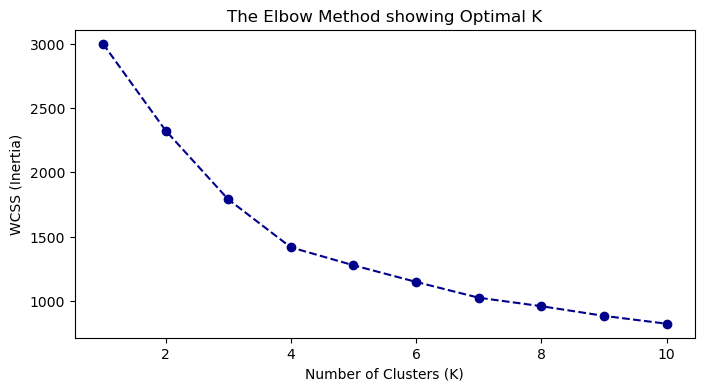

In [6]:
# Phase 2: Clustering-Based Segmentation

# The Elbow Method to Find Optimal Clusters

#Within-Cluster Sum of Squares (WCSS)
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title('The Elbow Method showing Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [7]:
#Training K-Means & Appending Labels
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
rfm_data['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score for K={optimal_k}: {silhouette_score(X_scaled, rfm_data['Cluster']):.4f}")
rfm_data['Cluster'].value_counts()

Silhouette Score for K=4: 0.2672


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster
1    341
2    257
0    223
3    179
Name: count, dtype: int64

In [8]:
#Phase 3: Customer Behavior Analysis

#Profiling the Clusters

cluster_profiles = rfm_data.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Segment Size'}).reset_index()

cluster_profiles

,Cluster,Recency,Frequency,Monetary,Segment Size
0,0,3.497758,6.363229,510.667828,223
1,1,40.448680,7.038123,745.540926,341
2,2,32.128405,6.221790,135.601485,257
3,3,32.675978,3.117318,640.948674,179


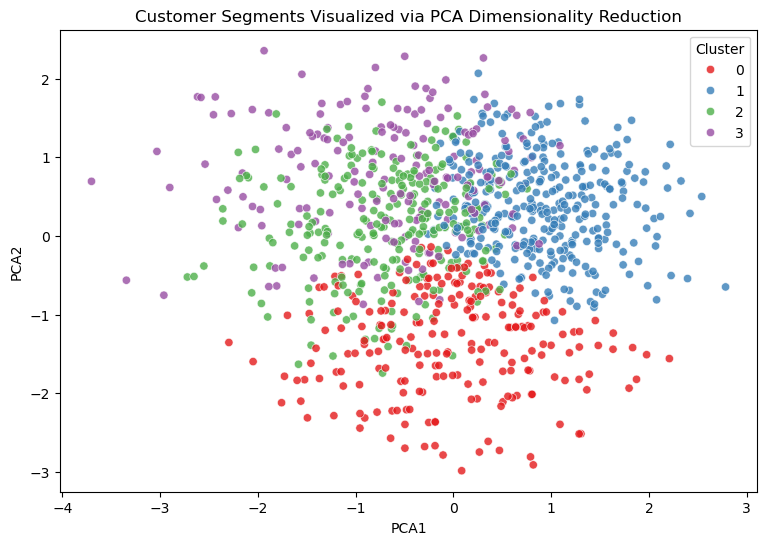

In [9]:
#Phase 4: Targeting Strategy & Business Recommendations

#Visualizing Segments in 2D space using PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = rfm_data['Cluster']

plt.figure(figsize=(9, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=pca_df, alpha=0.8)
plt.title('Customer Segments Visualized via PCA Dimensionality Reduction')
plt.show()
